# 🚀 RL Trading — Main Notebook

Entry point cho training và inference.

## 1. Training

In [ ]:
from src.logging_config import setup_logging
from src.config import Config
from src.training.trainer import Trainer

# Đọc configs/logging.yaml: console WARNING+, file DEBUG chia nhỏ 5MB
log_dir = setup_logging()
print(f"Log dir: {log_dir}")

cfg = Config.load("configs/")
trainer = Trainer(cfg)
trainer.run()

print(f"\n✅ Output directory: {trainer.run_dir}")

## 2. Evaluate (Test Set)

In [ ]:
# Evaluate trên test set với best model
test_results = trainer.evaluate()

# Export ROI table
trainer.export_roi_table(test_results)

## 3. Biểu đồ

In [ ]:
# Vẽ training curves + per-stock charts
# Tất cả output vào: outputs/output_<timestamp>/charts/
trainer.generate_charts(test_results)

print(f"Charts → {trainer.charts_dir}")

## 4. Inference (placeholder)

In [ ]:
from src.config import Config
from src.inference.inferencer import Inferencer

cfg = Config.load("configs/")
infer = Inferencer(cfg, model_path=str(trainer.weights_dir / "best_model.pkl"))

# Predict cho 1 stock
result = infer.predict("data/VNM.csv")
print(result)

## 5. Hyperparameter Sweep

Vòng lặp train từng bộ hyperparameter trọng tâm.  
Dùng `cfg.override()` để thay đổi giá trị trong memory — không sửa file config.

In [ ]:
# ════════════════════════════════════════════════════════════════
# Define experiments — mỗi dict là 1 run với overrides cụ thể
# Chỉ thay đổi 1 param (hoặc 1 cặp liên quan) mỗi lần
# ════════════════════════════════════════════════════════════════

EXPERIMENTS = [
    # ── Tier 1: gamma (discount factor) ─────────────────────────
    {"name": "gamma_090", "overrides": {"agent.gamma": 0.90}},
    {"name": "gamma_095", "overrides": {"agent.gamma": 0.95}},
    {"name": "gamma_097", "overrides": {"agent.gamma": 0.97}},
    {"name": "gamma_099", "overrides": {"agent.gamma": 0.99}},

    # ── Tier 1: learn_every (gradient updates frequency) ────────
    {"name": "learn_every_2", "overrides": {"training.learn_every": 2}},
    {"name": "learn_every_4", "overrides": {"training.learn_every": 4}},
    {"name": "learn_every_8", "overrides": {"training.learn_every": 8}},

    # ── Tier 1: lr + lr_decay (learning rate schedule) ──────────
    {"name": "lr_high",  "overrides": {"agent.lr": 0.001, "agent.lr_decay": 0.998}},
    {"name": "lr_mid",   "overrides": {"agent.lr": 0.0005, "agent.lr_decay": 0.995}},
    {"name": "lr_low",   "overrides": {"agent.lr": 0.0003, "agent.lr_decay": 0.999}},

    # ── Tier 2: batch_size + buffer_cap ─────────────────────────
    {"name": "batch128_buf50k", "overrides": {"agent.batch_size": 128, "agent.buffer_cap": 50000}},
    {"name": "batch256_buf20k", "overrides": {"agent.batch_size": 256, "agent.buffer_cap": 20000}},
    {"name": "batch256_buf50k", "overrides": {"agent.batch_size": 256, "agent.buffer_cap": 50000}},

    # ── Tier 2: tau (soft target update rate) ───────────────────
    {"name": "tau_001", "overrides": {"agent.tau": 0.001}},
    {"name": "tau_005", "overrides": {"agent.tau": 0.005}},
    {"name": "tau_01",  "overrides": {"agent.tau": 0.01}},

    # ── Tier 2: eps_decay (exploration schedule) ────────────────
    {"name": "eps_decay_990", "overrides": {"agent.eps_decay": 0.990}},
    {"name": "eps_decay_995", "overrides": {"agent.eps_decay": 0.995}},
    {"name": "eps_decay_997", "overrides": {"agent.eps_decay": 0.997}},
    {"name": "eps_decay_999", "overrides": {"agent.eps_decay": 0.999}},
]

print(f"Total experiments: {len(EXPERIMENTS)}")

In [ ]:
import json
from src.logging_config import setup_logging
from src.config import Config
from src.training.trainer import Trainer

setup_logging()

# ════════════════════════════════════════════════════════════════
# Sweep loop — train từng experiment
# ════════════════════════════════════════════════════════════════
results_summary = []

for i, exp in enumerate(EXPERIMENTS):
    print(f"\n{'='*60}")
    print(f"  [{i+1}/{len(EXPERIMENTS)}] Experiment: {exp['name']}")
    print(f"  Overrides: {exp['overrides']}")
    print(f"{'='*60}")

    # Load fresh config mỗi lần (reset về baseline)
    cfg = Config.load("configs/")

    # Override hyperparameters
    for key, val in exp["overrides"].items():
        cfg.override(key, val)

    # Train
    try:
        trainer = Trainer(cfg)
        trainer.run()

        # Collect result từ logs.json
        with open(trainer.run_dir / "logs.json", encoding="utf-8") as f:
            run_log = json.load(f)

        results_summary.append({
            "experiment": exp["name"],
            "overrides": exp["overrides"],
            "run_dir": str(trainer.run_dir),
            "test_metrics": run_log["result"].get("test_metrics", {}),
            "best_score": run_log["result"]["best_score"],
            "elapsed_min": run_log["elapsed_minutes"],
        })
        print(f"  ✅ Done: score={run_log['result']['best_score']:.4f}")

    except Exception as e:
        print(f"  ❌ Failed: {e}")
        results_summary.append({
            "experiment": exp["name"],
            "overrides": exp["overrides"],
            "run_dir": "FAILED",
            "test_metrics": {},
            "best_score": 0,
            "elapsed_min": 0,
        })

print(f"\n\n{'='*60}")
print(f"  All {len(EXPERIMENTS)} experiments completed!")
print(f"{'='*60}")

In [ ]:
import pandas as pd
import os

# ════════════════════════════════════════════════════════════════
# Summary table — so sánh tất cả experiments
# ════════════════════════════════════════════════════════════════
rows = []
for r in results_summary:
    avg = r["test_metrics"].get("average", {})
    rows.append({
        "Experiment": r["experiment"],
        "Return%": avg.get("return_pct", 0),
        "Sharpe": avg.get("sharpe", 0),
        "WinRate%": avg.get("win_rate", 0),
        "MaxDD%": avg.get("max_dd_pct", 0),
        "N_trades": avg.get("n_trades", 0),
        "PF": avg.get("profit_factor", 0),
        "Score": r["best_score"],
        "Time(min)": r["elapsed_min"],
    })

df_summary = pd.DataFrame(rows)

# Sort by Sharpe (chỉ số quan trọng nhất)
df_summary = df_summary.sort_values("Sharpe", ascending=False).reset_index(drop=True)

# Export CSV
os.makedirs("artifacts/outputs", exist_ok=True)
df_summary.to_csv("artifacts/outputs/hyperparam_sweep_results.csv", index=False)

print("\n📊 Hyperparameter Sweep Results (sorted by Sharpe):")
print("="*80)
display(df_summary)
print(f"\n💾 Saved → artifacts/outputs/hyperparam_sweep_results.csv")

## 6. Merge & Compare (Multi-machine Results)

Gộp kết quả từ nhiều thư mục `output_<timestamp>` (chạy trên nhiều máy khác nhau)  
để so sánh tất cả cấu hình trên cùng 1 biểu đồ.

In [1]:
import json
import os
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np

# ════════════════════════════════════════════════════════════════
# Scan tất cả output directories có logs.json hợp lệ
# ════════════════════════════════════════════════════════════════
OUTPUTS_DIR = Path("artifacts/outputs")

all_runs = []
for run_dir in sorted(OUTPUTS_DIR.glob("output_*")):
    logs_path = run_dir / "logs.json"
    if not logs_path.exists():
        continue
    with open(logs_path, encoding="utf-8") as f:
        data = json.load(f)
    # Skip logs cũ không có result
    if "result" not in data:
        continue
    all_runs.append(data)

print(f"Found {len(all_runs)} valid runs with test results.")

Found 34 valid runs with test results.


In [2]:
# ════════════════════════════════════════════════════════════════
# Detect experiment name bằng cách so sánh params vs baseline
# Baseline = config xuất hiện nhiều nhất (hoặc run đầu tiên)
# ════════════════════════════════════════════════════════════════

# Các param quan trọng cần theo dõi
TRACKED_PARAMS = {
    "agent.gamma": lambda d: d["parameters"]["agent"]["gamma"],
    "agent.lr": lambda d: d["parameters"]["agent"]["lr"],
    "agent.lr_decay": lambda d: d["parameters"]["agent"]["lr_decay"],
    "agent.tau": lambda d: d["parameters"]["agent"]["tau"],
    "agent.eps_decay": lambda d: d["parameters"]["agent"]["eps_decay"],
    "agent.batch_size": lambda d: d["parameters"]["agent"]["batch_size"],
    "agent.buffer_cap": lambda d: d["parameters"]["agent"]["buffer_cap"],
    "training.learn_every": lambda d: d["parameters"]["training"]["learn_every"],
}

def get_param_signature(run_data):
    """Trích xuất signature từ tracked params."""
    sig = {}
    for key, extractor in TRACKED_PARAMS.items():
        try:
            sig[key] = extractor(run_data)
        except (KeyError, TypeError):
            sig[key] = None
    return sig

# Tìm baseline = config xuất hiện nhiều nhất
from collections import Counter
sig_counts = Counter()
sigs = []
for run in all_runs:
    sig = get_param_signature(run)
    sig_key = json.dumps(sig, sort_keys=True)
    sig_counts[sig_key] += 1
    sigs.append(sig)

baseline_key = sig_counts.most_common(1)[0][0]
baseline_sig = json.loads(baseline_key)
print(f"Baseline config (most common, {sig_counts[baseline_key]} runs):")
for k, v in baseline_sig.items():
    print(f"  {k}: {v}")

# Detect tên experiment dựa trên diff vs baseline
def detect_experiment_name(sig, baseline):
    """So sánh sig vs baseline, trả về tên mô tả."""
    diffs = {}
    for key in baseline:
        if sig.get(key) != baseline.get(key) and sig.get(key) is not None:
            diffs[key] = sig[key]
    if not diffs:
        return "baseline"
    # Tạo tên từ diffs
    parts = []
    for key, val in diffs.items():
        short_key = key.split(".")[-1]  # gamma, lr, tau...
        # Format value: bỏ dấu chấm cho gọn
        if isinstance(val, float):
            val_str = str(val).replace("0.", "").rstrip("0") or "0"
        else:
            val_str = str(val)
        parts.append(f"{short_key}_{val_str}")
    return "_".join(parts)

# Gán tên + xử lý trùng
name_counter = defaultdict(int)
merged_results = []

for run, sig in zip(all_runs, sigs):
    name = detect_experiment_name(sig, baseline_sig)
    name_counter[name] += 1
    # Nếu trùng tên, thêm suffix
    if name_counter[name] > 1:
        display_name = f"{name}_run{name_counter[name]}"
    else:
        display_name = name

    avg = run["result"].get("test_metrics", {}).get("average", {})
    merged_results.append({
        "Experiment": display_name,
        "Return%": avg.get("return_pct", 0),
        "Sharpe": avg.get("sharpe", 0),
        "WinRate%": avg.get("win_rate", 0),
        "MaxDD%": avg.get("max_dd_pct", 0),
        "N_trades": avg.get("n_trades", 0),
        "PF": avg.get("profit_factor", 0),
        "Score": run["result"]["best_score"],
        "Time(min)": run.get("elapsed_minutes", 0),
        "run_dir": str(OUTPUTS_DIR / run["run_id"]),
        "run_id": run["run_id"],
    })

# Sau khi gán xong, fix lại tên cho run đầu tiên nếu có trùng
for name, count in name_counter.items():
    if count > 1:
        # Tìm entry đầu tiên có tên gốc và rename thành _run1
        for r in merged_results:
            if r["Experiment"] == name:
                r["Experiment"] = f"{name}_run1"
                break

print(f"\nDetected {len(merged_results)} experiments:")
for r in merged_results:
    print(f"  {r['Experiment']:30s} | Sharpe={r['Sharpe']:+.4f} | {r['run_id']}")

Baseline config (most common, 11 runs):
  agent.batch_size: 256
  agent.buffer_cap: 20000
  agent.eps_decay: 0.997
  agent.gamma: 0.97
  agent.lr: 0.0005
  agent.lr_decay: 0.995
  agent.tau: 0.005
  training.learn_every: 4

Detected 34 experiments:
  gamma_9                        | Sharpe=-0.1797 | output_20260528_221742
  gamma_95                       | Sharpe=-0.6770 | output_20260528_224742
  batch_size_128_buffer_cap_50000_run1 | Sharpe=-0.0835 | output_20260528_225105
  baseline_run1                  | Sharpe=+0.4937 | output_20260528_231129
  baseline_run2                  | Sharpe=-1.0151 | output_20260528_232147
  buffer_cap_50000_run1          | Sharpe=-1.6263 | output_20260528_233313
  lr_001_lr_decay_998_run1       | Sharpe=-0.6399 | output_20260528_234158
  tau_001_run1                   | Sharpe=-0.5590 | output_20260528_235504
  gamma_99                       | Sharpe=+0.2082 | output_20260528_235925
  baseline_run3                  | Sharpe=-0.2098 | output_20260529_00

In [3]:
# ════════════════════════════════════════════════════════════════
# Summary DataFrame — sort by Sharpe, highlight best
# ════════════════════════════════════════════════════════════════
df_merged = pd.DataFrame(merged_results)
df_merged = df_merged.sort_values("Sharpe", ascending=False).reset_index(drop=True)

# Export CSV
os.makedirs("artifacts/outputs", exist_ok=True)
df_merged.to_csv("artifacts/outputs/all_configs_comparison.csv", index=False)

print("📊 All Configs Comparison (sorted by Sharpe):")
print("═" * 100)
display(df_merged[["Experiment", "Return%", "Sharpe", "WinRate%", "MaxDD%", "N_trades", "PF", "Score", "Time(min)", "run_dir"]])

# ════════════════════════════════════════════════════════════════
# ⭐ Best Config
# ════════════════════════════════════════════════════════════════
best = df_merged.iloc[0]
print(f"\n{'═'*60}")
print(f"⭐ BEST CONFIG: {best['Experiment']}")
print(f"{'═'*60}")
print(f"   Run dir : {best['run_dir']}")
print(f"   Weights : {best['run_dir']}/weights/best_model.pkl")
print(f"   Sharpe  : {best['Sharpe']:+.4f}")
print(f"   Return% : {best['Return%']:+.2f}%")
print(f"   WinRate : {best['WinRate%']:.1f}%")
print(f"   MaxDD   : {best['MaxDD%']:.2f}%")
print(f"   PF      : {best['PF']:.2f}")
print(f"   Score   : {best['Score']:.4f}")
print(f"   Time    : {best['Time(min)']:.1f} min")

# Show per-stock breakdown for best
best_run = next(r for r in all_runs if r["run_id"] == best["run_id"])
print(f"\n   Per-stock metrics:")
for stock, metrics in best_run["result"]["test_metrics"].items():
    if stock == "average":
        continue
    print(f"     {stock}: Return={metrics['return_pct']:+.2f}% | Sharpe={metrics['sharpe']:+.4f} | WR={metrics['win_rate']:.1f}% | Trades={metrics['n_trades']}")

print(f"\n💾 Saved → artifacts/outputs/all_configs_comparison.csv")

📊 All Configs Comparison (sorted by Sharpe):
════════════════════════════════════════════════════════════════════════════════════════════════════


,Experiment,Return%,Sharpe,WinRate%,MaxDD%,N_trades,PF,Score,Time(min),run_dir
0,tau_01_run1,6.03,0.6008,59.7,-5.40,19,2.170000e+00,0.3456,77.78,artifacts\outputs\output_20260529_013135
1,baseline_run1,2.73,0.4937,70.2,-5.01,14,1.432925e+10,0.3758,21.71,artifacts\outputs\output_20260528_231129
2,learn_every_2,1.99,0.3942,65.3,-5.30,14,8.126500e+09,0.3679,94.02,artifacts\outputs\output_20260529_003822
3,eps_decay_999,3.13,0.2262,59.9,-6.39,17,6.900000e+00,0.4455,65.08,artifacts\outputs\output_20260529_045129
4,gamma_99,2.49,0.2082,61.2,-8.27,18,2.720000e+00,0.3730,38.95,artifacts\outputs\output_20260528_235925
5,baseline_run4,1.97,0.0123,60.2,-6.84,25,1.660000e+00,0.4521,51.52,artifacts\outputs\output_20260529_002849
6,batch_size_128_buffer_cap_50000_run1,1.14,-0.0835,61.3,-6.76,21,1.690000e+00,0.4632,20.36,artifacts\outputs\output_20260528_225105
7,lr_001_lr_decay_998_run2,1.42,-0.1322,61.0,-7.98,19,2.400000e+00,0.4086,33.41,artifacts\outputs\output_20260529_030515
8,gamma_9,1.48,-0.1797,56.1,-8.26,16,1.640000e+00,0.4398,29.64,artifacts\outputs\output_20260528_221742
9,baseline_run3,-0.46,-0.2098,65.9,-7.90,16,1.980000e+00,0.4692,77.93,artifacts\outputs\output_20260529_001338



════════════════════════════════════════════════════════════
⭐ BEST CONFIG: tau_01_run1
════════════════════════════════════════════════════════════
   Run dir : artifacts\outputs\output_20260529_013135
   Weights : artifacts\outputs\output_20260529_013135/weights/best_model.pkl
   Sharpe  : +0.6008
   Return% : +6.03%
   WinRate : 59.7%
   MaxDD   : -5.40%
   PF      : 2.17
   Score   : 0.3456
   Time    : 77.8 min

   Per-stock metrics:
     VNM: Return=-2.03% | Sharpe=-0.7437 | WR=54.5% | Trades=22
     FPT: Return=-6.05% | Sharpe=-1.6900 | WR=38.9% | Trades=18
     VIC: Return=+25.95% | Sharpe=+4.0000 | WR=78.6% | Trades=14
     HPG: Return=+6.24% | Sharpe=+0.8369 | WR=66.7% | Trades=24

💾 Saved → artifacts/outputs/all_configs_comparison.csv


C:\Users\bnquys\AppData\Local\Temp\ipykernel_10792\3797592956.py:41: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig("artifacts/outputs/comparison_metrics.png", dpi=150, bbox_inches="tight")
d:\bnquys\Source\stock-trend-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


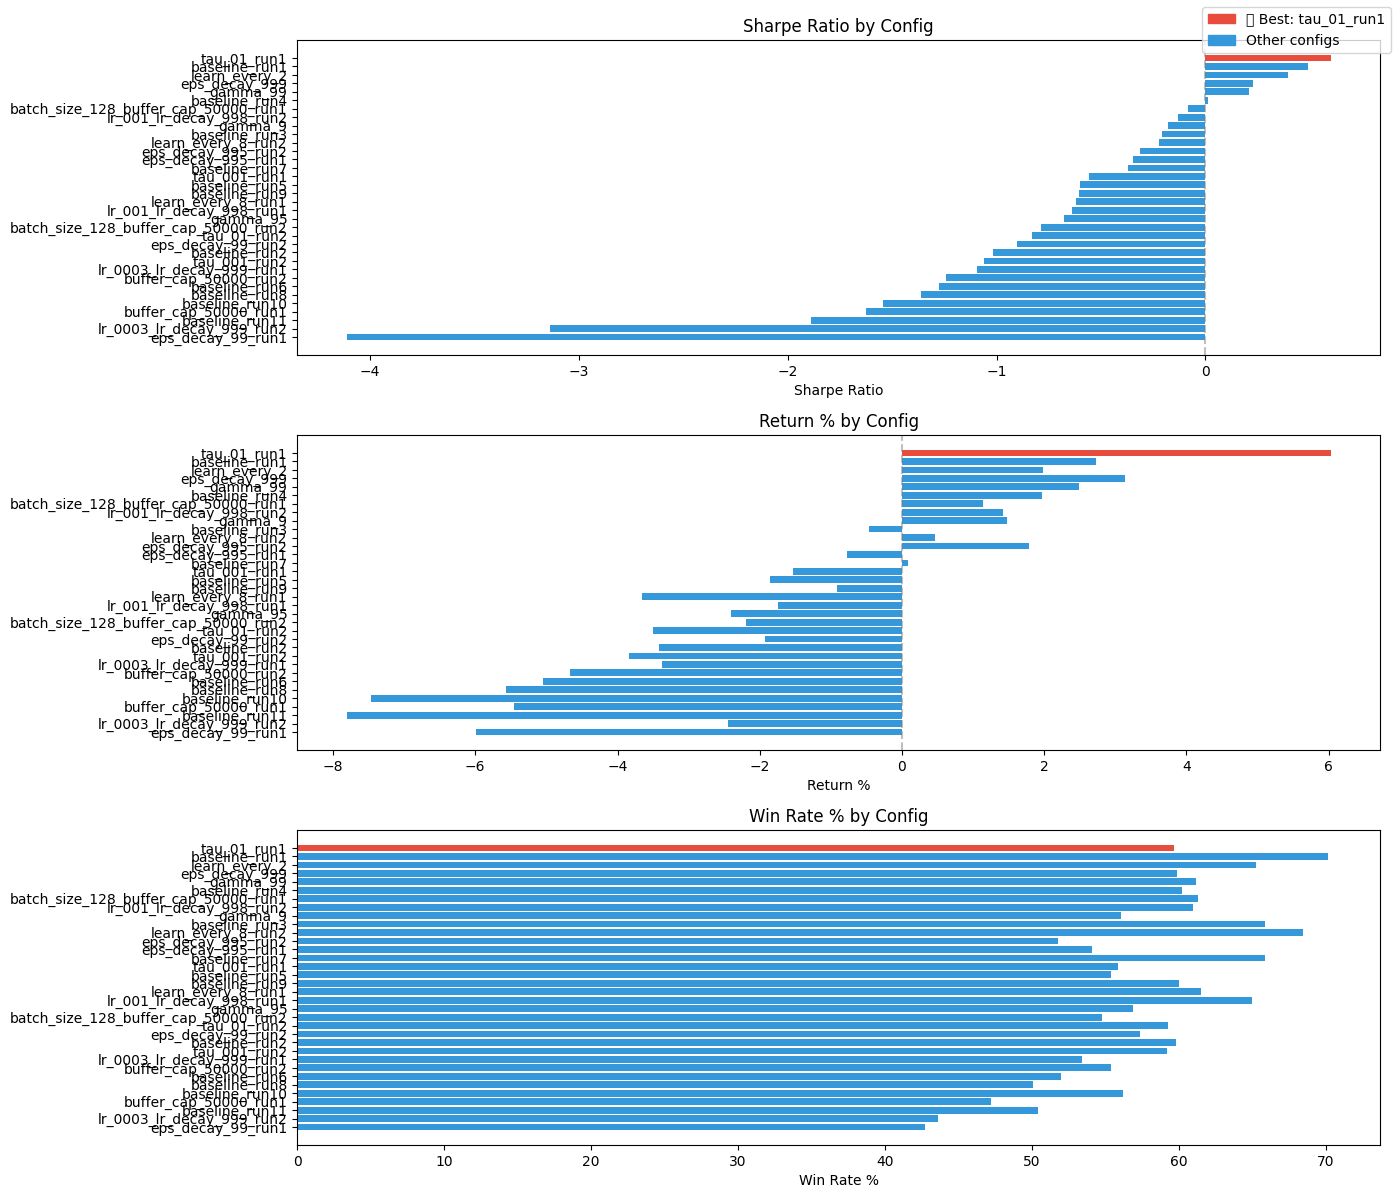

💾 Saved → artifacts/outputs/comparison_metrics.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ════════════════════════════════════════════════════════════════
# Biểu đồ 1: Bar chart so sánh Sharpe, Return%, WinRate%
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

experiments = df_merged["Experiment"].tolist()
best_name = best["Experiment"]
colors = ["#e74c3c" if exp == best_name else "#3498db" for exp in experiments]

# Sharpe
axes[0].barh(experiments, df_merged["Sharpe"], color=colors)
axes[0].set_xlabel("Sharpe Ratio")
axes[0].set_title("Sharpe Ratio by Config")
axes[0].axvline(x=0, color="gray", linestyle="--", alpha=0.5)
axes[0].invert_yaxis()

# Return%
axes[1].barh(experiments, df_merged["Return%"], color=colors)
axes[1].set_xlabel("Return %")
axes[1].set_title("Return % by Config")
axes[1].axvline(x=0, color="gray", linestyle="--", alpha=0.5)
axes[1].invert_yaxis()

# WinRate%
axes[2].barh(experiments, df_merged["WinRate%"], color=colors)
axes[2].set_xlabel("Win Rate %")
axes[2].set_title("Win Rate % by Config")
axes[2].invert_yaxis()

# Legend
legend_patches = [
    mpatches.Patch(color="#e74c3c", label=f"⭐ Best: {best_name}"),
    mpatches.Patch(color="#3498db", label="Other configs"),
]
fig.legend(handles=legend_patches, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("artifacts/outputs/comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → artifacts/outputs/comparison_metrics.png")

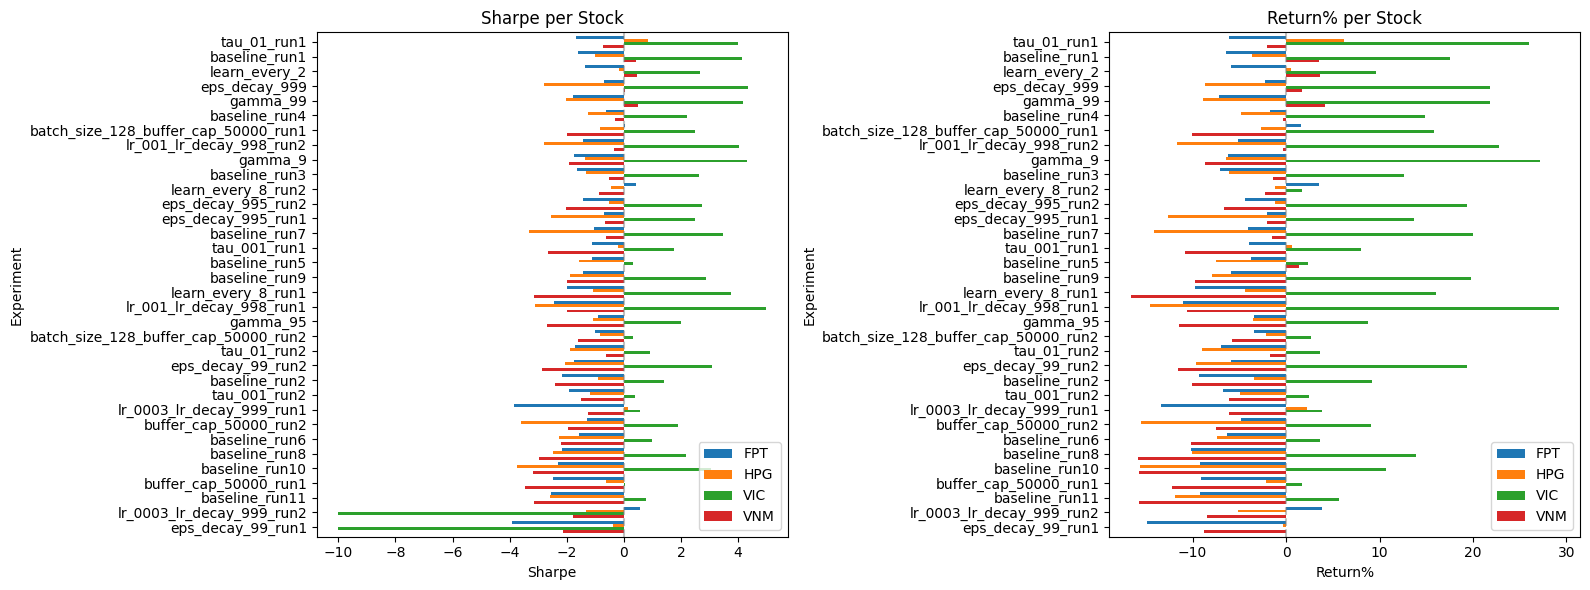

💾 Saved → artifacts/outputs/comparison_per_stock.png


In [5]:
# ════════════════════════════════════════════════════════════════
# Biểu đồ 2: Per-stock Sharpe grouped bar chart
# ════════════════════════════════════════════════════════════════
stocks = [s for s in best_run["result"]["test_metrics"].keys() if s != "average"]

# Build per-stock data
per_stock_data = []
for run in all_runs:
    run_name = next(r["Experiment"] for r in merged_results if r["run_id"] == run["run_id"])
    for stock in stocks:
        metrics = run["result"]["test_metrics"].get(stock, {})
        per_stock_data.append({
            "Experiment": run_name,
            "Stock": stock,
            "Sharpe": metrics.get("sharpe", 0),
            "Return%": metrics.get("return_pct", 0),
        })

df_per_stock = pd.DataFrame(per_stock_data)

# Plot grouped bar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ["Sharpe", "Return%"]):
    pivot = df_per_stock.pivot(index="Experiment", columns="Stock", values=metric)
    # Reorder by overall Sharpe
    pivot = pivot.reindex(df_merged["Experiment"])
    pivot.plot(kind="barh", ax=ax, width=0.8)
    ax.set_title(f"{metric} per Stock")
    ax.set_xlabel(metric)
    ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
    ax.invert_yaxis()
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("artifacts/outputs/comparison_per_stock.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → artifacts/outputs/comparison_per_stock.png")

C:\Users\bnquys\AppData\Local\Temp\ipykernel_10792\3337296598.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(all_runs))


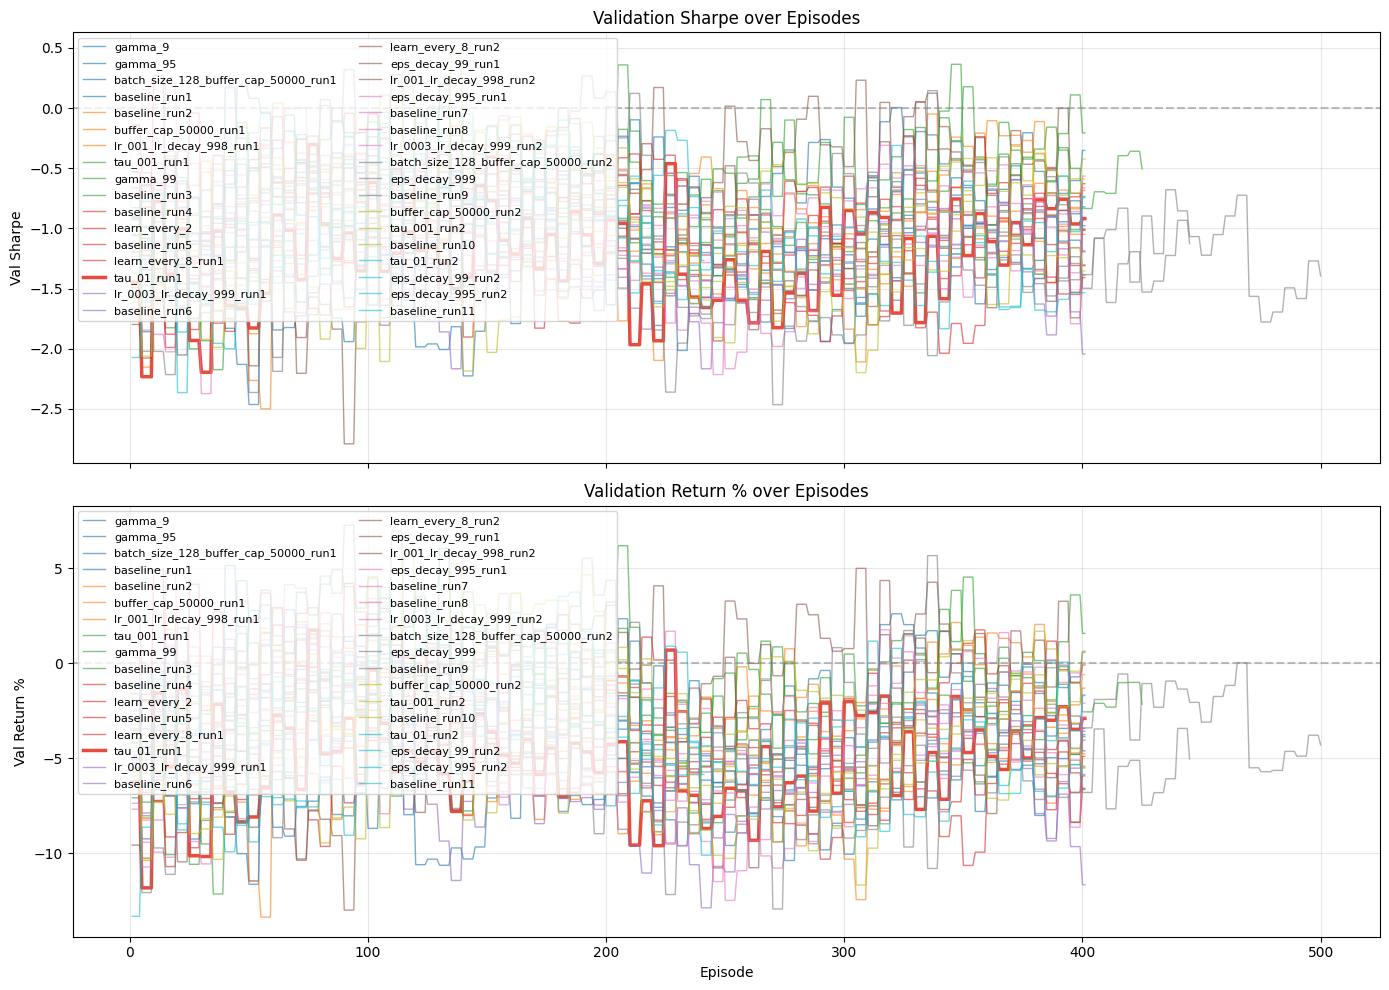

💾 Saved → artifacts/outputs/comparison_training_curves.png


In [6]:
# ════════════════════════════════════════════════════════════════
# Biểu đồ 3: Training curves overlay (val_sharpe & val_return)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

cmap = plt.cm.get_cmap("tab10", len(all_runs))

for i, run in enumerate(all_runs):
    run_dir = OUTPUTS_DIR / run["run_id"]
    tlog_path = run_dir / "training_log.json"
    if not tlog_path.exists():
        continue

    with open(tlog_path, encoding="utf-8") as f:
        tlog = json.load(f)

    episodes = [entry["episode"] for entry in tlog]
    val_sharpe = [entry.get("val_sharpe", np.nan) for entry in tlog]
    val_return = [entry.get("val_return", np.nan) for entry in tlog]

    run_name = next(r["Experiment"] for r in merged_results if r["run_id"] == run["run_id"])
    is_best = (run["run_id"] == best["run_id"])
    lw = 2.5 if is_best else 1.0
    alpha = 1.0 if is_best else 0.6
    color = "#e74c3c" if is_best else cmap(i)

    axes[0].plot(episodes, val_sharpe, label=run_name, color=color, linewidth=lw, alpha=alpha)
    axes[1].plot(episodes, val_return, label=run_name, color=color, linewidth=lw, alpha=alpha)

axes[0].set_ylabel("Val Sharpe")
axes[0].set_title("Validation Sharpe over Episodes")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

axes[1].set_ylabel("Val Return %")
axes[1].set_xlabel("Episode")
axes[1].set_title("Validation Return % over Episodes")
axes[1].legend(loc="upper left", fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("artifacts/outputs/comparison_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → artifacts/outputs/comparison_training_curves.png")